# Predictive Modeling

To develop a robust classification system capable of identifying heart disease risk while ensuring high clinical reliability. focusing on a ready machine learning pipeline and Moving beyond basic predictive modeling, this notebook implements an end-to-end scikit-learn pipeline that integrates automated data scaling, cross-validation, and an extensive comparative analysis of both simple baseline models and advanced ensemble learners.

In [321]:
# import the required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score

In [322]:
# import data
heart_df = pd.read_csv('/content/drive/MyDrive/ML datasets/heart_disease.csv')

In [323]:
# defining the target and feature variables
x = heart_df.drop('target', axis=1)
y = heart_df['target']

In [324]:
# seperating training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 524)

In [325]:
# define the models
model = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "XGboost": XGBClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [326]:
# setting up the stratified K-Fold
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 524)

# define scoring methods
scoring = ['accuracy', 'precision', 'recall', 'f1']


In [327]:
results = {}
for name, model in model.items():
  pipe = Pipeline([
      ('scaler', StandardScaler()),
      ('classifier', model)
  ])

  # running the cross validation
  cv_results = cross_validate(pipe, x_train, y_train, cv = skf, scoring = scoring)

  # Store average results
  results[name] = {
      'Accuracy': np.mean(cv_results['test_accuracy']),
      'Recall': np.mean(cv_results['test_recall']),
      'Precision': np.mean(cv_results['test_precision']),
      'F1-Score': np.mean(cv_results['test_f1'])
  }

In [328]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Recall,Precision,F1-Score
Logistic Regression,0.843902,0.898599,0.818312,0.856321
KNN,0.840244,0.867983,0.832343,0.849192
SVM,0.892683,0.910448,0.886398,0.898085
Random Forest,0.969512,0.959832,0.981281,0.970189
XGboost,0.974390,0.974118,0.976993,0.975377
Gradient Boosting,0.953659,0.955238,0.955561,0.955248


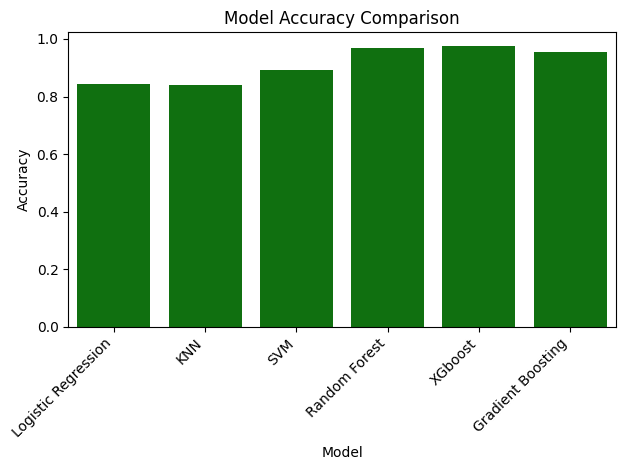

In [329]:
# accuracy plot
plot_results_df = results_df.reset_index().rename(columns={'index': 'Model'})
sns.barplot(data = plot_results_df, y = 'Accuracy', x = 'Model', color = 'green')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

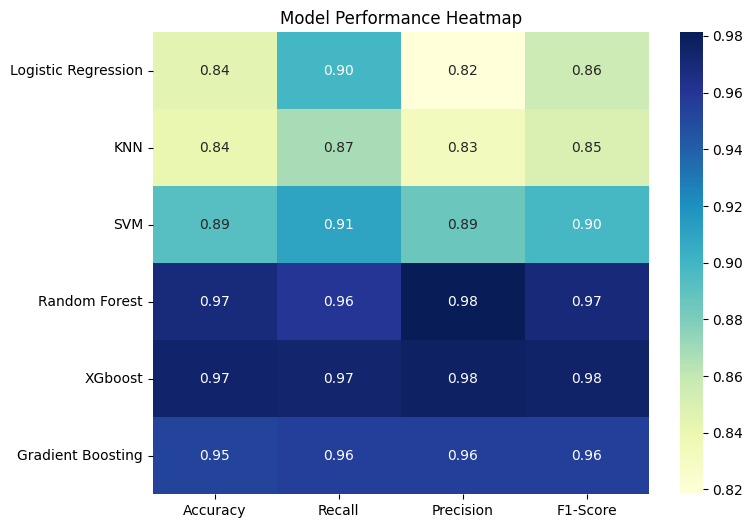

In [330]:
plt.figure(figsize=(8, 6))
sns.heatmap(results_df, annot = True, cmap = "YlGnBu", fmt = ".2f")
plt.title("Model Performance Heatmap")
plt.show()